# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

The objective of this project is to analyze whether Bitcoin market sentiment
(Fear & Greed Index) influences trader performance on Hyperliquid.

This analysis explores:

- Trading profitability
- Win/Loss ratio
- Leverage usage
- Trading volume
- Trader behavior
- Relationship between market sentiment and trading outcomes

The findings aim to uncover patterns that can help design smarter trading strategies.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

# Display all columns
pd.set_option("display.max_columns", None)

# Better chart style
sns.set_style("whitegrid")

## Load the Datasets

In [2]:
trades = pd.read_csv("D:\python\Primetrabe\historical_data.csv")

In [3]:
sentiment = pd.read_csv("D:\python\Primetrabe\\fear_greed_index.csv")

In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Dataset Information

In [6]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
print(trades.duplicated().sum())

print(sentiment.duplicated().sum())

0
0


In [11]:
trades = trades.drop_duplicates()

sentiment = sentiment.drop_duplicates()

## Convert Date Columns

In [12]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [13]:
trades[["Timestamp", "Timestamp IST"]].head()

,Timestamp,Timestamp IST
0,1.730000e+12,02-12-2024 22:50
1,1.730000e+12,02-12-2024 22:50
2,1.730000e+12,02-12-2024 22:50
3,1.730000e+12,02-12-2024 22:50
4,1.730000e+12,02-12-2024 22:50


In [14]:
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"])

trades["Date"] = trades["Timestamp"].dt.date

In [15]:
trades["Timestamp IST"].dtype

dtype('O')

In [16]:
trades["Timestamp IST"].head(10)

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
5    02-12-2024 22:50
6    02-12-2024 22:50
7    02-12-2024 22:50
8    02-12-2024 22:50
9    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [17]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    errors="coerce"
)

In [18]:
trades["Timestamp IST"].dtype

dtype('<M8[ns]')

In [19]:
trades["Hour"] = trades["Timestamp IST"].dt.hour
trades["Weekday"] = trades["Timestamp IST"].dt.day_name()
trades["Date"] = trades["Timestamp IST"].dt.date

In [20]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [21]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [22]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [23]:
sentiment = sentiment.rename(columns={
    "date": "Date",
    "classification": "Classification"
})

In [24]:
print(sentiment.columns)

Index(['timestamp', 'value', 'Classification', 'Date'], dtype='object')


In [25]:
merged = pd.merge(
    trades,
    sentiment,
    on="Date",
    how="left"
)

In [26]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Hour,Weekday,timestamp,value,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-02-12,22.0,Monday,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-02-12,22.0,Monday,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-02-12,22.0,Monday,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-02-12,22.0,Monday,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-02-12,22.0,Monday,1.707716e+09,70.0,Greed


## Feature Engineering

In [27]:
merged["Trade Result"] = merged["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

In [28]:
mapping = {
    "Extreme Fear": 0,
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}

merged["Sentiment Score"] = merged["Classification"].map(mapping)

In [29]:
merged["Trade Value"] = merged["Size USD"]

In [30]:
merged["Hour"] = merged["Timestamp IST"].dt.hour

In [31]:
merged["Weekday"] = merged["Timestamp IST"].dt.day_name()

In [32]:
def session(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

merged["Session"] = merged["Hour"].apply(session)

# Exploratory Data Analysis

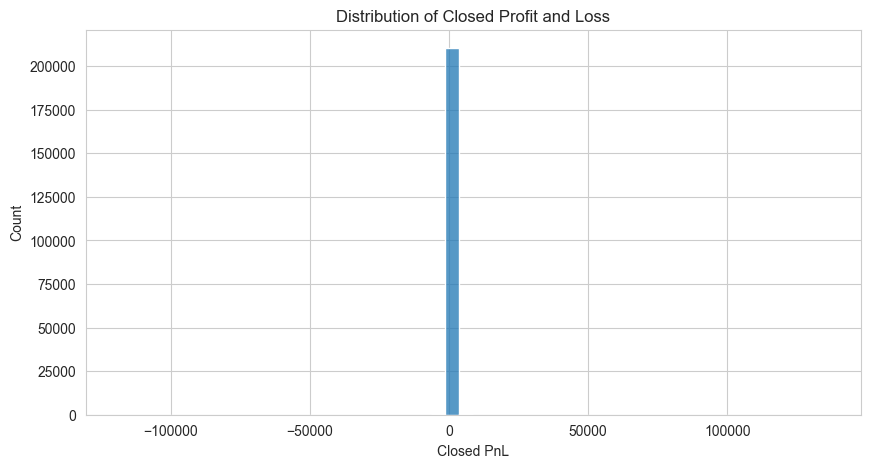

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(merged["Closed PnL"], bins=50)

plt.title("Distribution of Closed Profit and Loss")

plt.show()

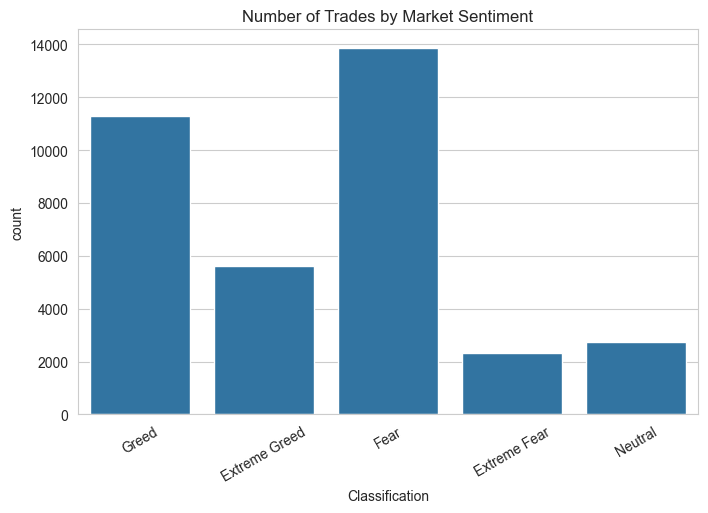

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=merged, x="Classification")

plt.title("Number of Trades by Market Sentiment")

plt.xticks(rotation=30)

plt.show()

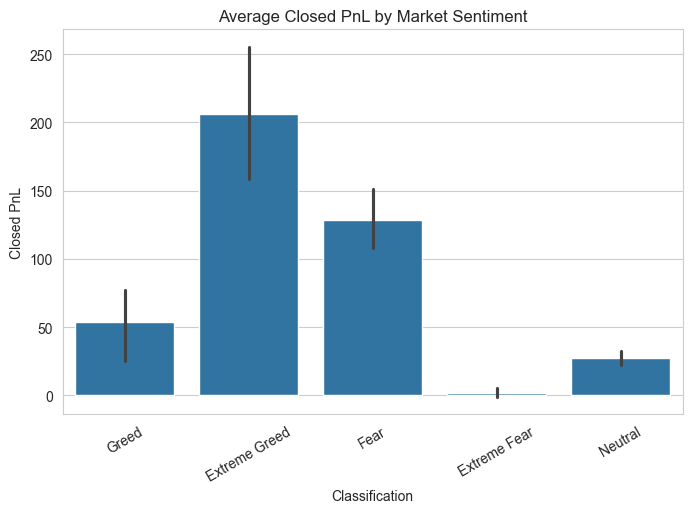

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="Classification",
    y="Closed PnL",
    estimator="mean"
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=30)

plt.show()

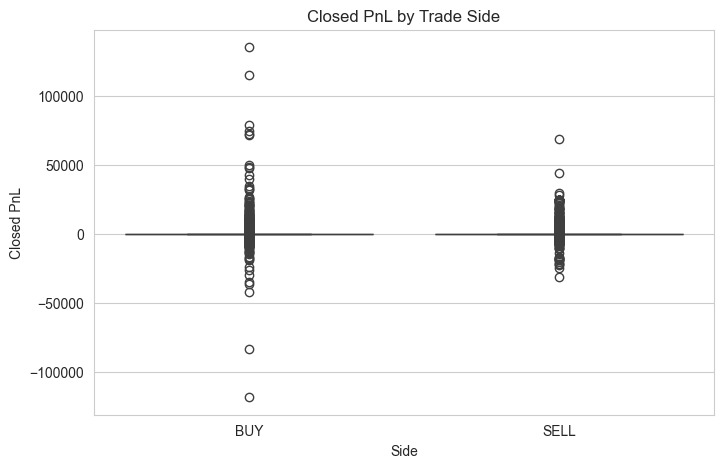

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="Side",
    y="Closed PnL"
)

plt.title("Closed PnL by Trade Side")

plt.show()

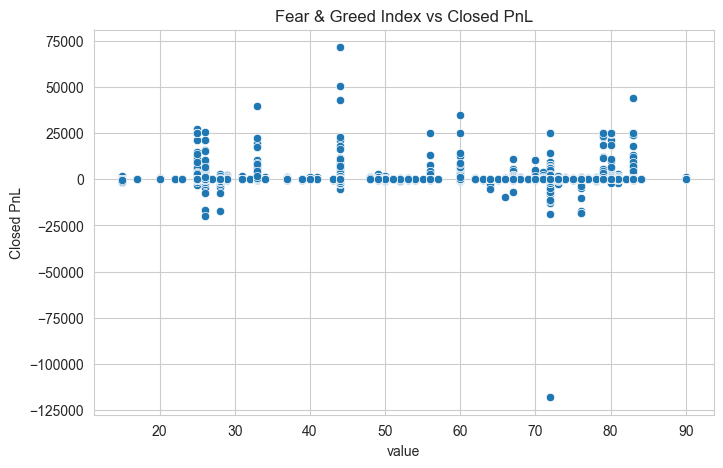

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x="value",
    y="Closed PnL"
)

plt.title("Fear & Greed Index vs Closed PnL")

plt.show()

In [38]:
merged[
[
"Closed PnL",
"Trade Value",
"Execution Price",
"Fee",
"Sentiment Score"
]
].corr()

,Closed PnL,Trade Value,Execution Price,Fee,Sentiment Score
Closed PnL,1.000000,0.123589,-0.006505,0.084020,0.011881
Trade Value,0.123589,1.000000,0.189855,0.745939,-0.025294
Execution Price,-0.006505,0.189855,1.000000,0.225265,0.022507
Fee,0.084020,0.745939,0.225265,1.000000,-0.005735
Sentiment Score,0.011881,-0.025294,0.022507,-0.005735,1.000000


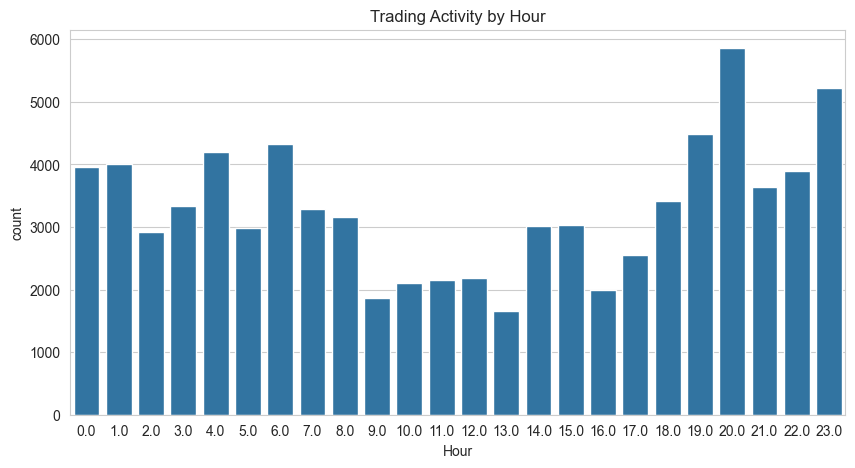

In [39]:
plt.figure(figsize=(10,5))

sns.countplot(data=merged, x="Hour")

plt.title("Trading Activity by Hour")

plt.show()

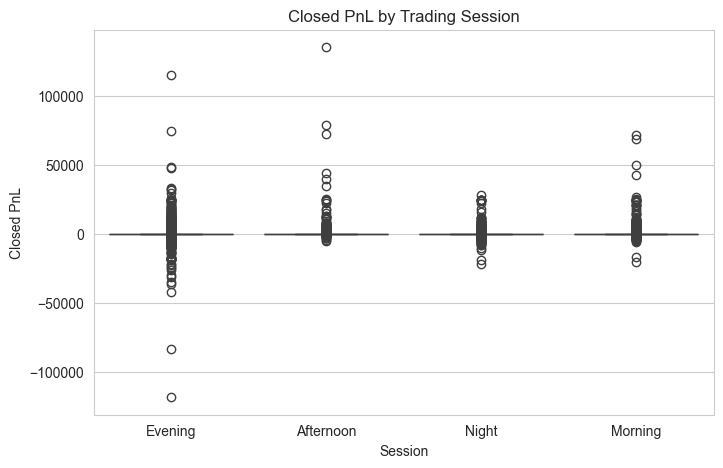

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="Session",
    y="Closed PnL"
)

plt.title("Closed PnL by Trading Session")

plt.show()

compares all sentiment categories

In [41]:
from scipy.stats import f_oneway

groups = [
    group["Closed PnL"].values
    for _, group in merged.groupby("Classification")
]

f_oneway(*groups)

F_onewayResult(statistic=np.float64(18.150894970637555), pvalue=np.float64(6.624400733621604e-15))

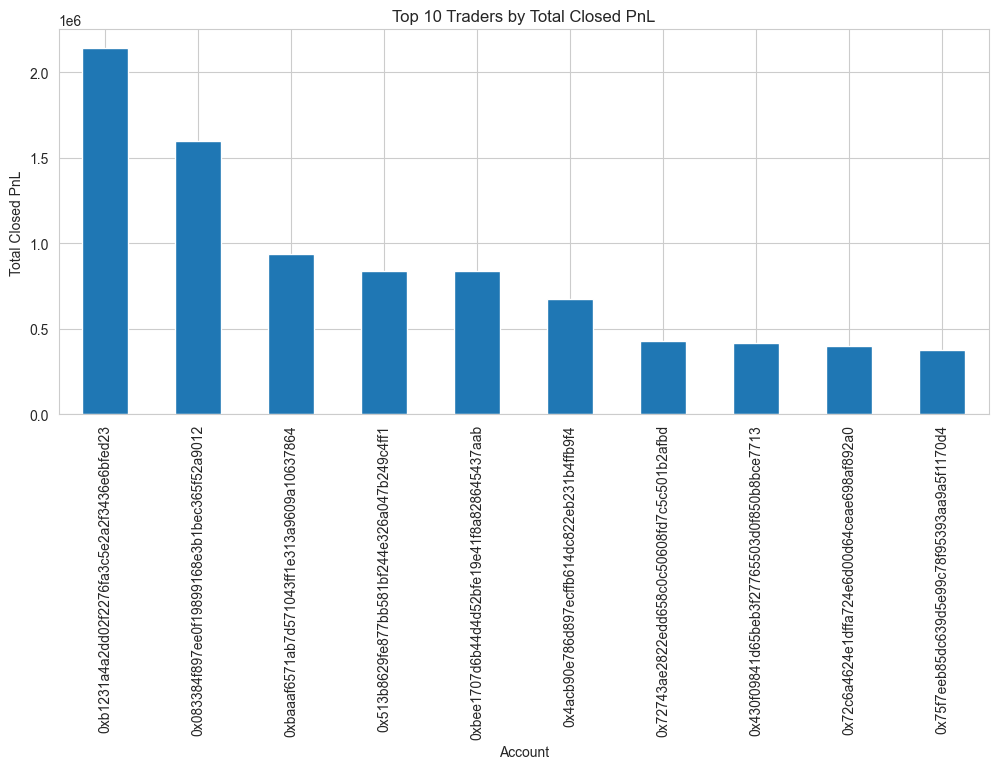

In [42]:
top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total Closed PnL")

plt.ylabel("Total Closed PnL")

plt.show()

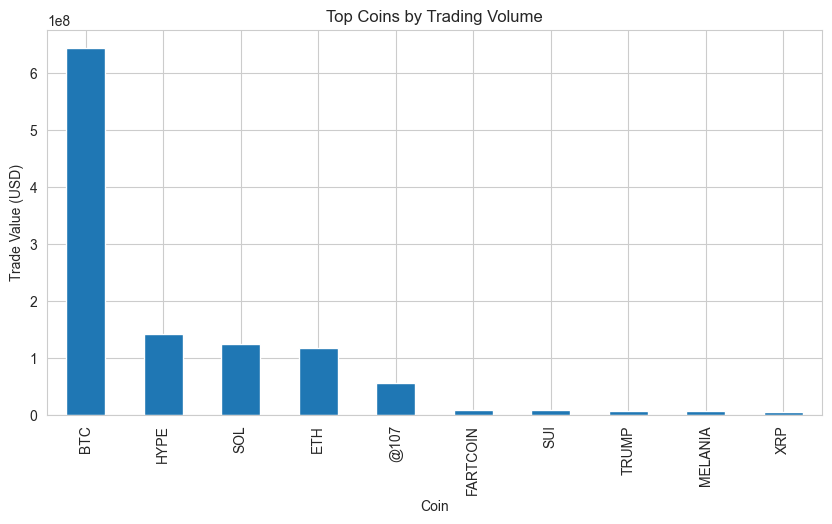

In [43]:
plt.figure(figsize=(10,5))

merged.groupby("Coin")["Trade Value"]\
      .sum()\
      .sort_values(ascending=False)\
      .head(10)\
      .plot(kind="bar")

plt.title("Top Coins by Trading Volume")

plt.ylabel("Trade Value (USD)")

plt.show()

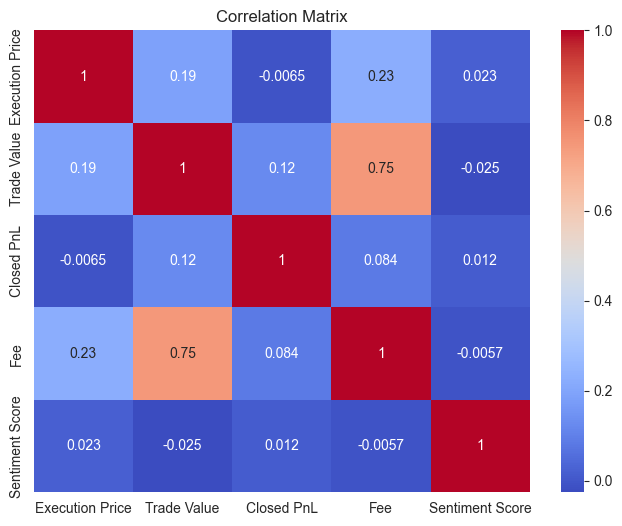

In [44]:
plt.figure(figsize=(8,6))

corr = merged[
    ["Execution Price", "Trade Value", "Closed PnL", "Fee", "Sentiment Score"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

## Statistical Analysis

Question 1

Does market sentiment affect profit?

In [45]:
merged.groupby("Classification")["Closed PnL"].describe()

,count,mean,std,min,25%,50%,75%,max
Classification,,,,,,,,
Extreme Fear,2326.0,1.891632,76.727713,-1430.889856,0.0,0.00000,0.298102,2020.000000
Extreme Greed,5621.0,205.816345,1861.557119,-18360.670070,0.0,0.96048,30.153710,44223.451870
Fear,13869.0,128.287950,1342.348497,-19841.240140,0.0,0.00000,8.201820,71535.716740
Greed,11292.0,53.988003,1399.468182,-117990.104100,0.0,0.00000,13.441364,34903.817100
Neutral,2756.0,27.088803,142.945889,-1032.981540,0.0,0.00000,9.267691,2979.554311


Question 2

Compare Fear vs Greed.

In [46]:
from scipy.stats import ttest_ind

fear = merged.loc[
    merged["Classification"] == "Fear",
    "Closed PnL"
]

greed = merged.loc[
    merged["Classification"] == "Greed",
    "Closed PnL"
]

t_stat, p_value = ttest_ind(fear, greed, nan_policy="omit")

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.284086506432704
P-value: 1.8417230078275656e-05


Question 3:

Are traders more successful during Fear or Greed?

In [47]:
win_rate = merged.groupby("Classification")["Trade Result"] \
                 .value_counts(normalize=True) \
                 .mul(100) \
                 .rename("Percentage") \
                 .reset_index()

win_rate

,Classification,Trade Result,Percentage
0,Extreme Fear,Loss,70.722270
1,Extreme Fear,Profit,29.277730
2,Extreme Greed,Profit,55.328233
3,Extreme Greed,Loss,44.671767
4,Fear,Loss,61.821328
5,Fear,Profit,38.178672
6,Greed,Loss,56.429330
7,Greed,Profit,43.570670
8,Neutral,Loss,50.507983
9,Neutral,Profit,49.492017


Question 4:

Do traders take bigger positions during Greed?

In [48]:
merged.groupby("Classification")["Trade Value"].mean()

Classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Trade Value, dtype: float64

Question 5:

Which market condition generated the highest total profit?

In [49]:
merged.groupby("Classification")["Closed PnL"].sum()

Classification
Extreme Fear     4.399937e+03
Extreme Greed    1.156894e+06
Fear             1.779226e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Name: Closed PnL, dtype: float64

Question 6: Shows risk distribution

<Axes: xlabel='Classification', ylabel='Closed PnL'>

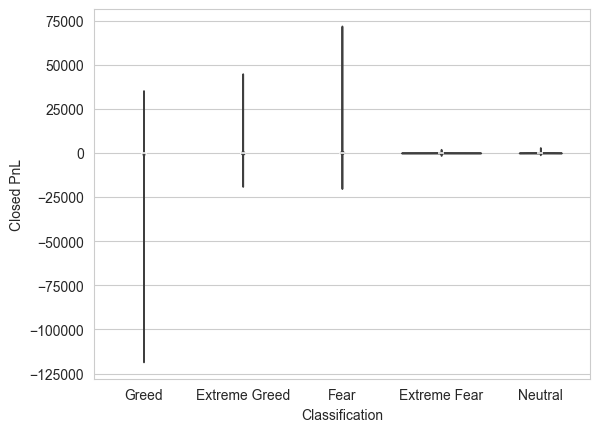

In [50]:
sns.violinplot(
    data=merged,
    x="Classification",
    y="Closed PnL"
)

Question 7:

Which coins are most profitable?

In [51]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values()

Coin
TRUMP      -3.648249e+05
FARTCOIN   -1.006872e+05
ADA        -2.811346e+04
IO         -2.189391e+04
PAXG       -1.868887e+04
                ...     
BTC         8.680447e+05
ETH         1.319979e+06
SOL         1.639556e+06
HYPE        1.948485e+06
@107        2.783913e+06
Name: Closed PnL, Length: 246, dtype: float64

Question 8: Trading Activity by Weekday

<Axes: xlabel='Weekday', ylabel='count'>

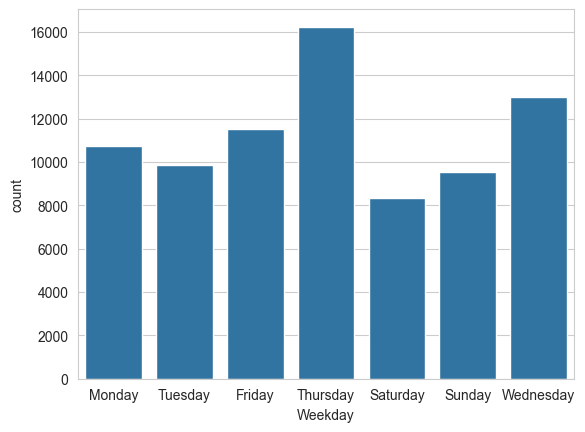

In [52]:
sns.countplot(
    data=merged,
    x="Weekday"
)

Question 9: Average Fee

In [53]:
merged.groupby("Coin")["Fee"].mean()

Coin
@1        0.017494
@10       0.003129
@100      0.011202
@103      0.001917
@107      0.198494
            ...   
kBONK     0.161529
kFLOKI    0.371406
kNEIRO    0.061758
kPEPE     0.245883
kSHIB     0.597762
Name: Fee, Length: 246, dtype: float64

Question 10: Most Active Traders

In [54]:
merged["Account"].value_counts().head(20)

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     3052
0xbd

Question 11: Profit by Side

In [55]:
merged.groupby("Side")["Closed PnL"].mean()

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64

Question 12: Best Trading Session

In [56]:
merged.groupby("Session")["Closed PnL"].mean()

Session
Afternoon    101.333763
Evening       36.110742
Morning      114.126449
Night         55.326877
Name: Closed PnL, dtype: float64

Business Recommendations

The assignment explicitly asks for:

smarter trading strategies

This means we should include recommendations such as:

Example (only if our analysis supports):

Reduce position sizes during Extreme Greed due to increased variability in returns.
Consider stricter risk management during periods where win rates decline.
Focus on coins with consistently positive average PnL rather than only high trading volume.
Monitor market sentiment as one input to trading decisions, alongside technical and fundamental analysis.